In [1]:
"""Goal: Develop a regression model that accurately predicts an individual's medical expenses based on their:
age, BMI, and lifestyle choices (like smoking)."""

#Import Relevant Libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics

# hide warnings
import warnings
warnings.filterwarnings('ignore')


In [2]:
# load dataset and investigate

df = pd.read_csv(r"insurance.csv")

print(df.describe().T)

print(df.shape)

print(df.columns)

print(df.isnull().sum())


           count          mean           std        min         25%       50%  \
age       1338.0     39.207025     14.049960    18.0000    27.00000    39.000   
bmi       1338.0     30.663397      6.098187    15.9600    26.29625    30.400   
children  1338.0      1.094918      1.205493     0.0000     0.00000     1.000   
charges   1338.0  13270.422265  12110.011237  1121.8739  4740.28715  9382.033   

                   75%          max  
age          51.000000     64.00000  
bmi          34.693750     53.13000  
children      2.000000      5.00000  
charges   16639.912515  63770.42801  
(1338, 7)
Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


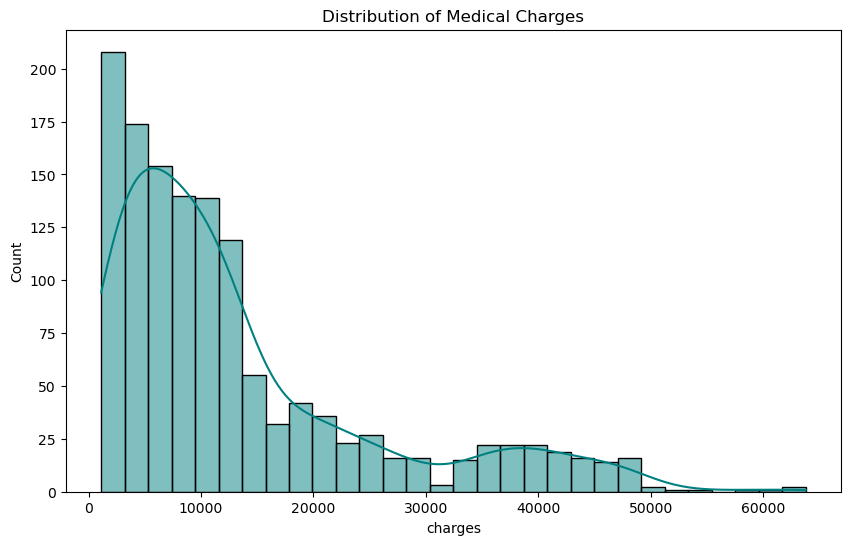

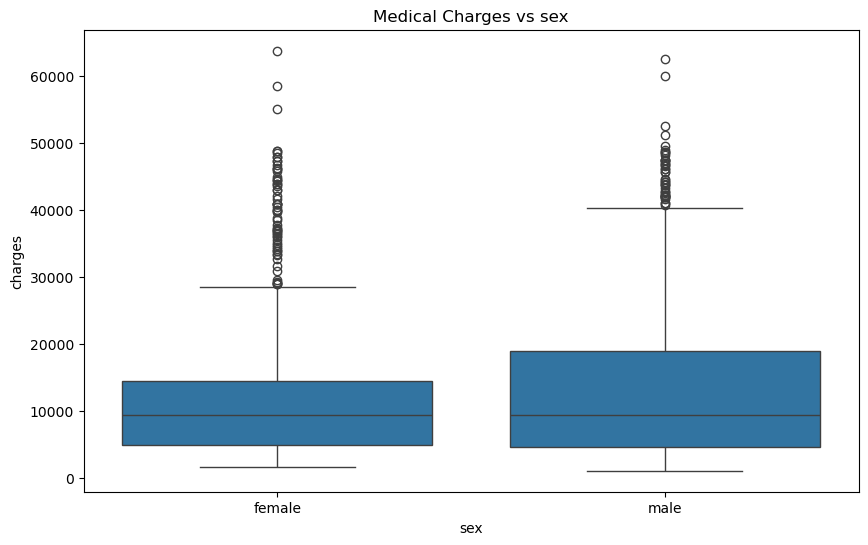

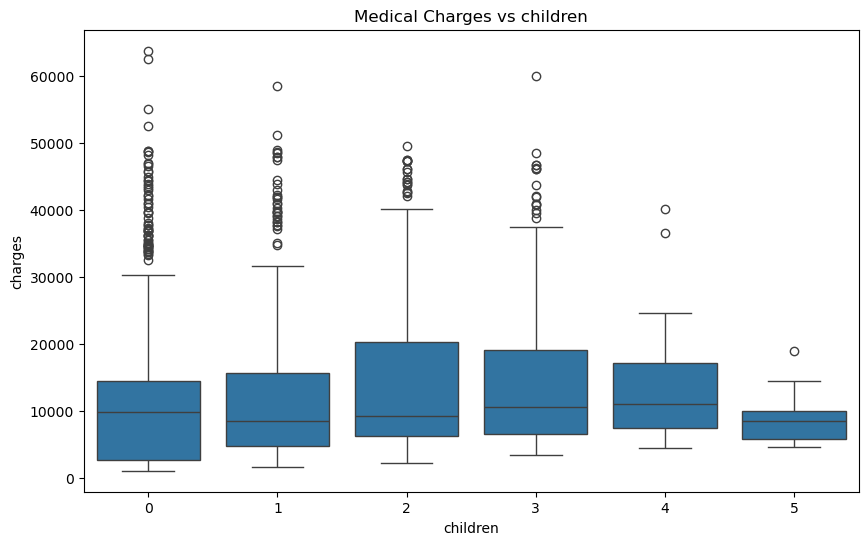

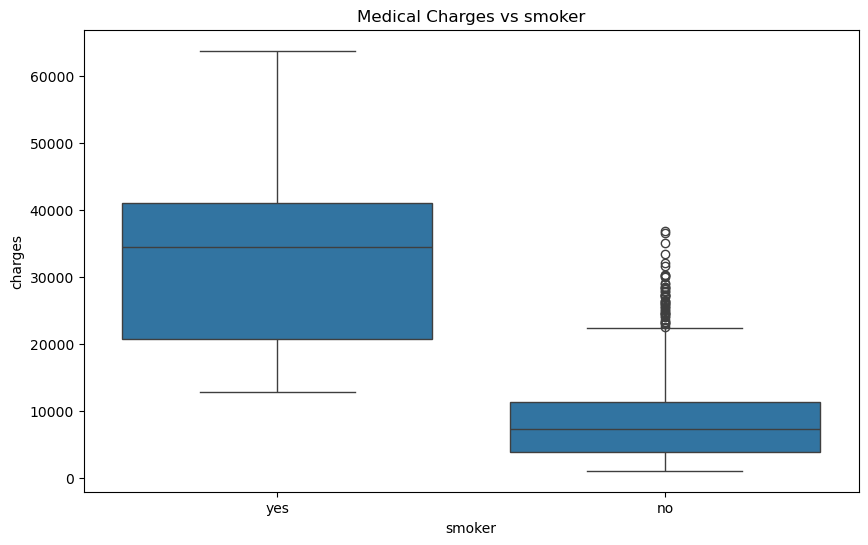

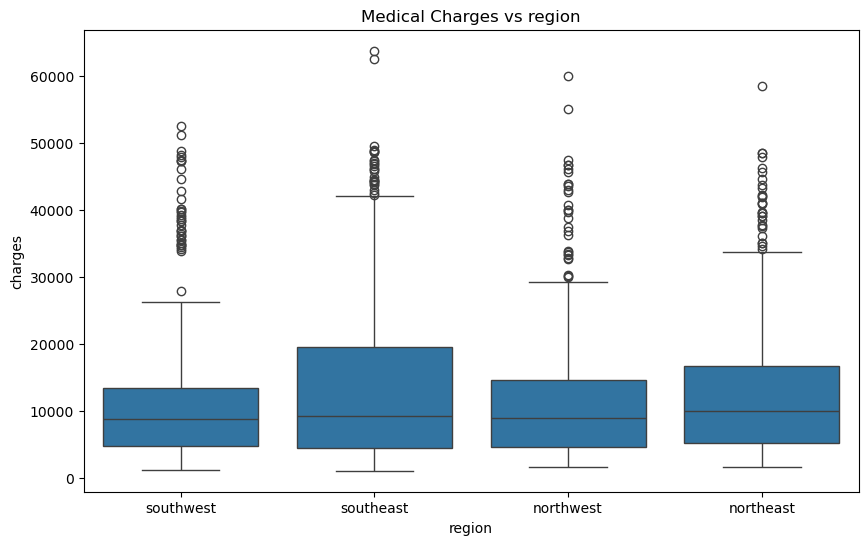

None


In [3]:
"""No null values"""

#Preprocessing: Visualise the data using seaborn
#Target Variable: Charges. 

plt.figure(figsize = (10, 6))
sns.histplot(df['charges'], kde = True, color = 'Teal') 
plt.title('Distribution of Medical Charges')
plt.show()

# correlation between Medical charges and each of the column variables
def boxplt(df): 
    for cols in df.columns:
        if cols != 'age' and cols != 'charges' and cols != 'bmi':
            plt.figure(figsize=(10, 6))
            sns.boxplot(x= cols, y='charges', data=df)
            plt.title(f'Medical Charges vs {cols}')
            plt.show()

print(boxplt(df))

In [4]:
#Correlation investigation - turning categorical data to numerical data using OneHotEncoder from Scikit Learn Library
from sklearn.feature_selection import r_regression
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(drop='first', sparse_output=False)

# features
cat_features = df.select_dtypes(include = ['object']).columns
num_features = df.select_dtypes(exclude = ['object']).drop(columns=['charges']).columns

# arrays of cat_data
ohe_array = ohe.fit_transform(df[cat_features])
ohe_col_names = ohe.get_feature_names_out(cat_features)

# build final dataframe
X_encoded_parts = pd.DataFrame(ohe_array, columns = ohe_col_names, index = df.index)
X = pd.concat([df[num_features], X_encoded_parts], axis = 1)
y = df['charges']

# correlation formula
correlation = r_regression(X, y)

# final results
corr_results = pd.Series(correlation, index = X.columns)
print("Correlation with Medical Charges:")
print(corr_results.sort_values(ascending = False))


Correlation with Medical Charges:
smoker_yes          0.787251
age                 0.299008
bmi                 0.198341
region_southeast    0.073982
children            0.067998
sex_male            0.057292
region_northwest   -0.039905
region_southwest   -0.043210
dtype: float64


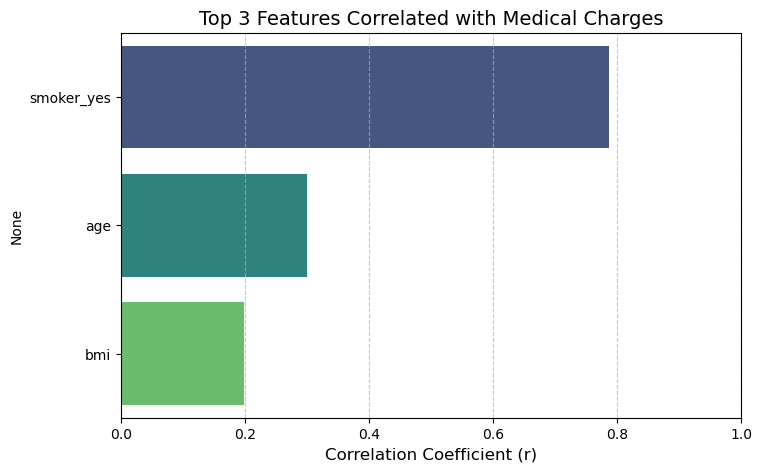

In [5]:
# top 3 visual for correlation with Medical Charges
top_3_corr = corr_results.sort_values(ascending=False).head(3)

# create corr plot
plt.figure(figsize=(8, 5))
sns.barplot(x=top_3_corr.values, y=top_3_corr.index, palette='viridis')
plt.title('Top 3 Features Correlated with Medical Charges', fontsize=14)
plt.xlabel('Correlation Coefficient (r)', fontsize=12)
plt.xlim(0, 1)  # Since smoker is nearly 0.8, this keeps the scale clear
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()


In [6]:
""" Smoking is the highest Medical Cost Driver"""
# Linear Regression Model Algorithm Building

# randomly splitting test and train data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

# Model Fitting
model = LinearRegression()
model.fit(X_train, y_train)

# predictions - model testing
predictions = model.predict(X_test)

# array of predictions
import numpy as np
print(pd.DataFrame(predictions).mean())

0    13187.557732
dtype: float64


In [7]:
# simple model evaulation using r squared score, mean absolute error, mean squared error etc.
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error, root_mean_squared_error

#Evaluation 
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = root_mean_squared_error(y_test, predictions)
r_squared = r2_score(y_test, predictions)

print(f"Mean Absolute Error: {mae:.2f}")
print(f"Mean Squared Error: {mse:.2f}")
print(f"Root Mean Sqaured Error: {rmse:.2f}")
print(f"R Squared Score: {r_squared:.4f}")


Mean Absolute Error: 4181.19
Mean Squared Error: 33596915.85
Root Mean Sqaured Error: 5796.28
R Squared Score: 0.7836


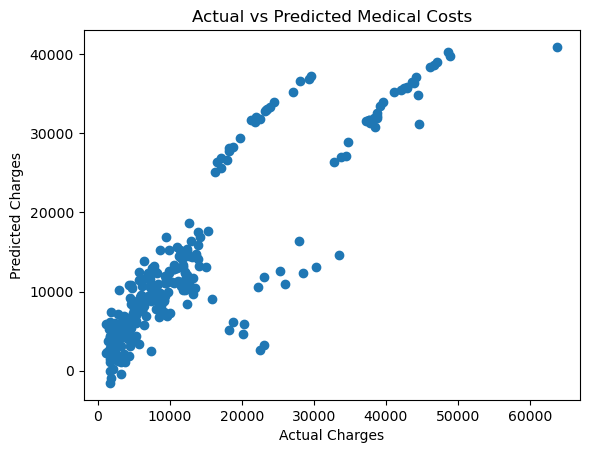

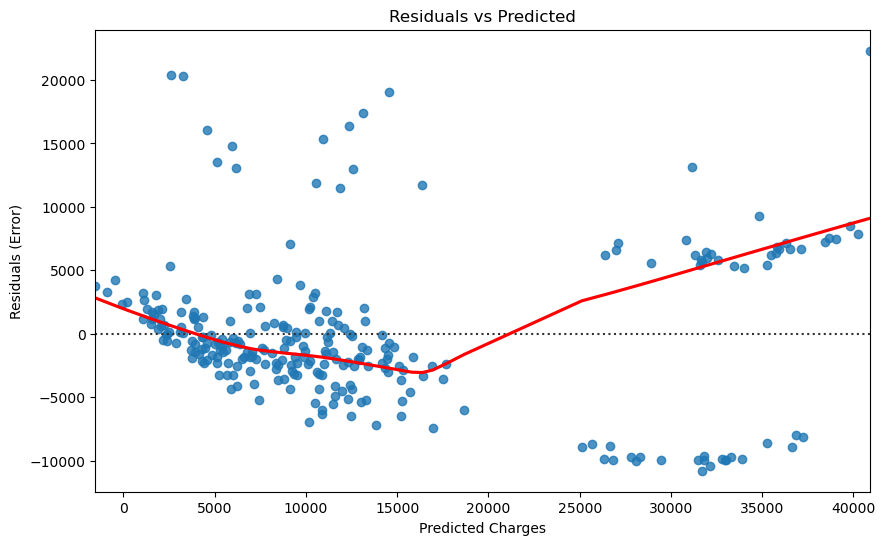

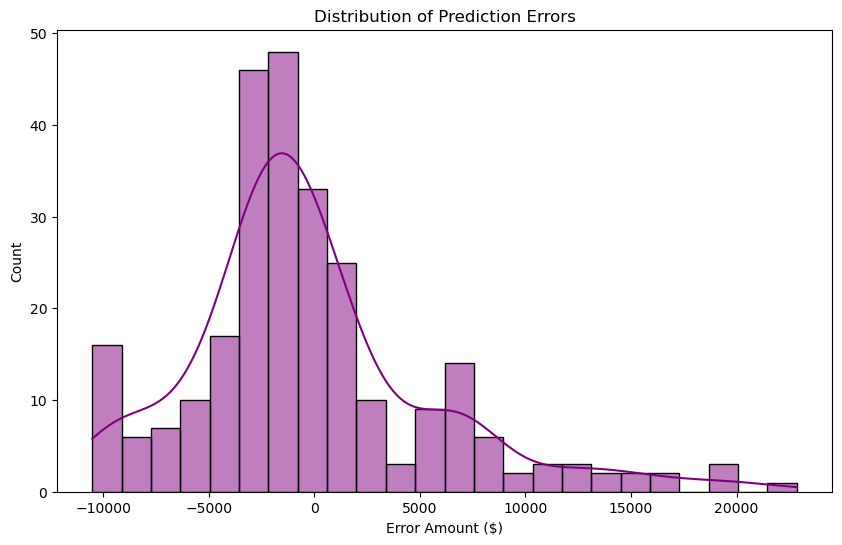

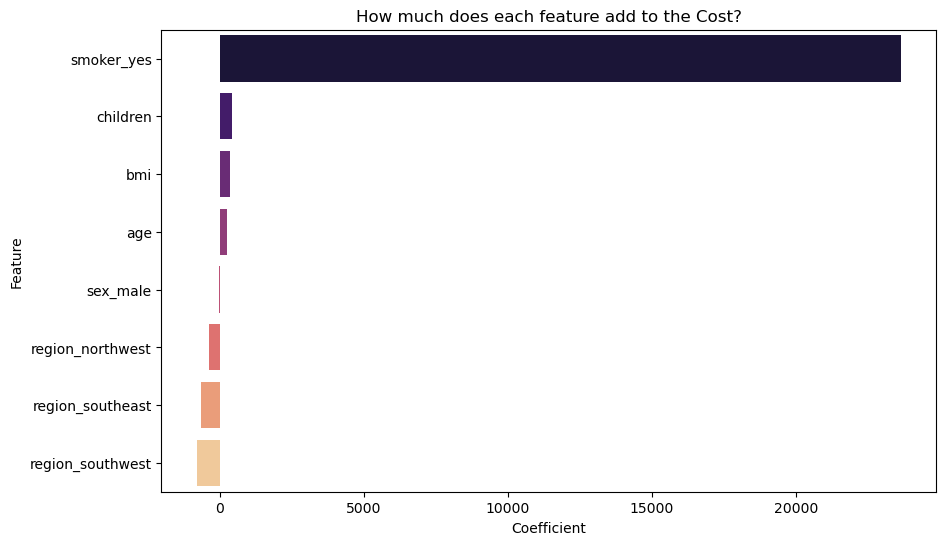

In [8]:
#Visualisation to compare test data and model predictions 
plt.scatter(y_test, predictions)
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Actual vs Predicted Medical Costs')
plt.show()

# REsiduals Plot - investigating model accuracy
residuals = y_test - predictions
plt.figure(figsize=(10, 6))
sns.residplot(x=predictions, y=residuals, lowess=True, line_kws={'color': 'red'})
plt.xlabel('Predicted Charges')
plt.ylabel('Residuals (Error)')
plt.title('Residuals vs Predicted')
plt.show()

# Histogram - distribution of errors
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, color='purple')
plt.title('Distribution of Prediction Errors')
plt.xlabel('Error Amount ($)')
plt.show()

# Feature Importance Bar Chart - for the use of One Hot Encoder
# DataFrame of the coefficients
importance = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
importance = importance.sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance, x='Coefficient', y='Feature', palette='magma')
plt.title('How much does each feature add to the Cost?')
plt.show()


In [9]:
# Regularisation to prevent overfitting {Lasso, Ordinary least Sqaures and Ridge}
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
# model call
scaler = StandardScaler()

# fitting and transforming
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# using X_train_scaled on Ridge Model.
ridge_model = Ridge(alpha = 1)
ridge_model.fit(X_train_scaled, y_train)

#predictions of model using test data
ridge_predictions = ridge_model.predict(X_test_scaled)
print(f"Ridge R2 Score: {ridge_model.score(X_test_scaled, y_test):.4f}")

#model evaluation
print(f"Residuals: {pd.DataFrame(y_test - ridge_predictions).round(2)}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, ridge_predictions):.2f}")
print(f"Mean Squared Error: {mean_squared_error(y_test, ridge_predictions):.2f}")
print(f"Root Mean Squared Error:{root_mean_squared_error(y_test, ridge_predictions):.2f}")
print(f"R Squared Score: {r2_score(y_test, ridge_predictions):.4f}")



Ridge R2 Score: 0.7835
Residuals:        charges
764     123.14
887   -1801.17
890   -7503.01
1293   -157.16
259    6790.16
...        ...
109    8016.91
575     461.59
535   -1625.19
543   22875.86
846   -2445.98

[268 rows x 1 columns]
Mean Absolute Error: 4182.80
Mean Squared Error: 33604973.54
Root Mean Squared Error:5796.98
R Squared Score: 0.7835


In [10]:
# using X_train_scaled on Lasso Model
lasso_model = Lasso(alpha = 100)

# fitting and transforming
lasso_model.fit(X_train_scaled, y_train)

# predictions
lasso_predictions = lasso_model.predict(X_test_scaled)
print(f"Lasso Model R2 Score: {lasso_model.score(X_test_scaled, y_test)}")

#model evaluation
print(f"Residuals: \n{pd.DataFrame(y_test - lasso_predictions).round(2)}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, lasso_predictions):.2f}")
print(f"Mean Squared Error: {mean_squared_error(y_test, lasso_predictions):.2f}")
print(f"Root Mean Squared Error: {root_mean_squared_error(y_test, lasso_predictions):.2f}")
print(f"R Squared Score: {r2_score(y_test, lasso_predictions):.4f}")



Lasso Model R2 Score: 0.7806320248423892
Residuals: 
       charges
764     448.99
887   -1935.11
890   -7308.05
1293   -123.30
259    6821.80
...        ...
109    8131.68
575     389.96
535   -1366.39
543   23243.80
846   -2514.66

[268 rows x 1 columns]
Mean Absolute Error: 4210.60
Mean Squared Error: 34056599.87
Root Mean Squared Error: 5835.80
R Squared Score: 0.7806


In [11]:
# compare coefficients
coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Lasso_Coeff': lasso_model.coef_,
    'Ridge_Coeff': ridge_model.coef_
})

print(coeff_df)


            Feature  Lasso_Coeff  Ridge_Coeff
0               age  3528.802468  3611.354521
1               bmi  1892.789994  2034.362351
2          children   424.978753   516.761658
3          sex_male     0.000000    -8.615975
4        smoker_yes  9453.068030  9549.276683
5  region_northwest    -0.000000  -157.633519
6  region_southeast   -15.589796  -288.545534
7  region_southwest  -104.379764  -348.270354


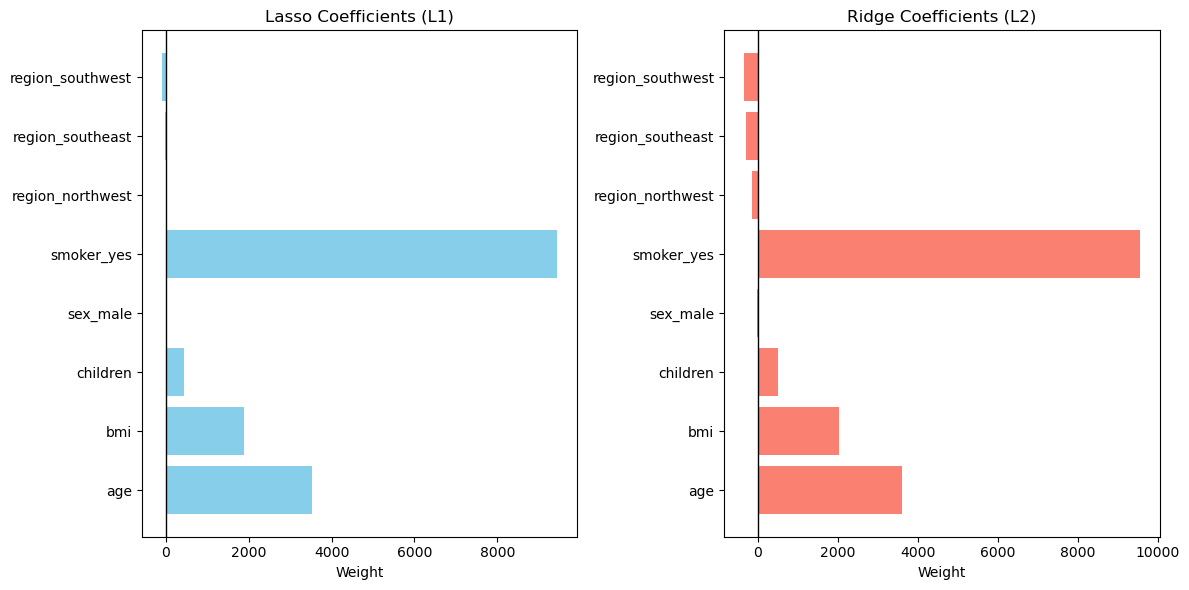

In [12]:
# plotting
features = X.columns
lasso_coefs = lasso_model.coef_
ridge_coefs = ridge_model.coef_

plt.figure(figsize=(12, 6))

# Lasso Subplot
plt.subplot(1, 2, 1)
plt.barh(features, lasso_coefs, color='skyblue')
plt.title('Lasso Coefficients (L1)')
plt.axvline(0, color='black', lw=1)
plt.xlabel('Weight')

# Ridge Subplot
plt.subplot(1, 2, 2)
plt.barh(features, ridge_coefs, color='salmon')
plt.title('Ridge Coefficients (L2)')
plt.axvline(0, color='black', lw=1)
plt.xlabel('Weight')

plt.tight_layout()
plt.show()



Text(0, 0.5, 'Error')

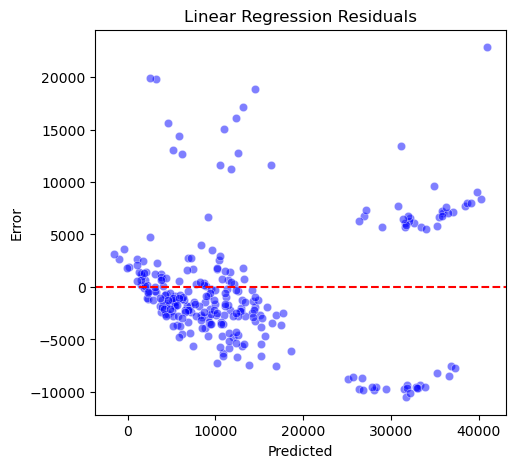

In [19]:
plt.figure(figsize=(18, 5))

#Linear Residuals
plt.subplot(1, 3, 1)
sns.scatterplot(x=predictions, y=res_linear, alpha=0.5, color='blue')
plt.axhline(0, color='red', linestyle='--')
plt.title('Linear Regression Residuals')
plt.xlabel('Predicted')
plt.ylabel('Error')

